In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                              precision_score, recall_score,
                              confusion_matrix, classification_report,
                              RocCurveDisplay)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")


Load Processed Data

In [2]:
df = pd.read_csv('../data/processed_churn.csv')
print("Shape:", df.shape)
print("Churn distribution:\n", df['Churn'].value_counts())


Shape: (7043, 48)
Churn distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


Split Features and Target

In [3]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (7043, 47)
Target shape: (7043,)


Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       # ensures same class ratio in train and test
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target distribution:\n", y_train.value_counts(normalize=True).round(3))
print("Test target distribution:\n", y_test.value_counts(normalize=True).round(3))


Train size: (5634, 47)
Test size: (1409, 47)

Train target distribution:
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64
Test target distribution:
 Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


Scale Features

In [5]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Scaling done.")


Scaling done.


Train & Evaluate 5 Models

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'XGBoost':             XGBClassifier(use_label_encoder=False,
                                         eval_metric='logloss',
                                         random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    preds = model.predict(X_test_sc)
    probs = model.predict_proba(X_test_sc)[:, 1]

    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, preds), 3),
        'ROC-AUC':   round(roc_auc_score(y_test, probs), 3),
        'F1-Score':  round(f1_score(y_test, preds), 3),
        'Precision': round(precision_score(y_test, preds), 3),
        'Recall':    round(recall_score(y_test, preds), 3)
    }

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print(results_df)


                     Accuracy  ROC-AUC  F1-Score  Precision  Recall
Logistic Regression     0.808    0.847     0.597      0.672   0.537
XGBoost                 0.787    0.822     0.573      0.613   0.537
Random Forest           0.778    0.819     0.540      0.599   0.492
KNN                     0.760    0.776     0.536      0.551   0.521
Decision Tree           0.742    0.682     0.533      0.514   0.553


Visualize Model Comparison

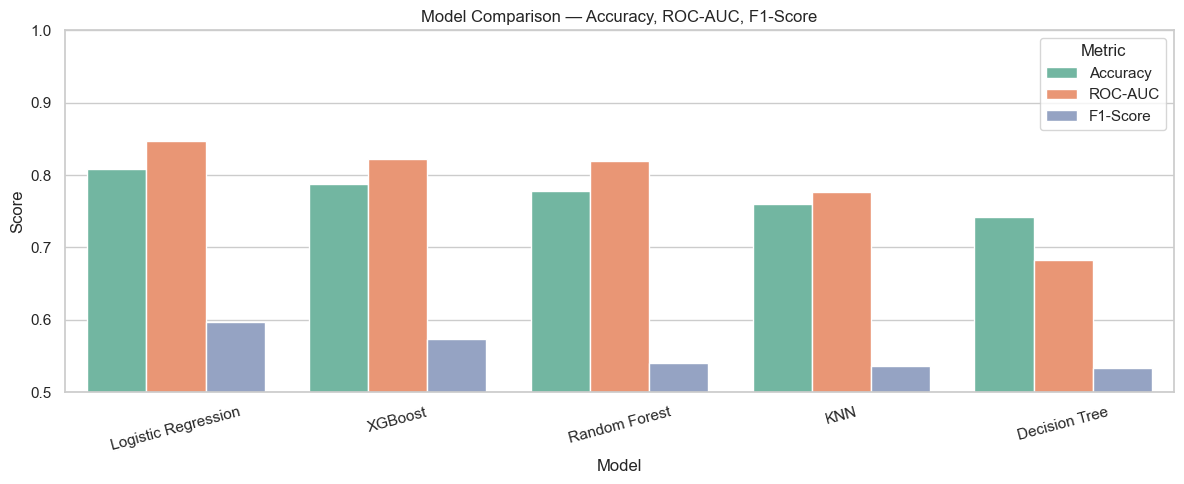

In [7]:
results_df_plot = results_df[['Accuracy', 'ROC-AUC', 'F1-Score']].reset_index()
results_df_melted = results_df_plot.melt(id_vars='index',
                                          var_name='Metric',
                                          value_name='Score')

plt.figure(figsize=(12, 5))
sns.barplot(data=results_df_melted, x='index', y='Score',
            hue='Metric', palette='Set2')
plt.title('Model Comparison — Accuracy, ROC-AUC, F1-Score')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()


ROC Curves for All Models

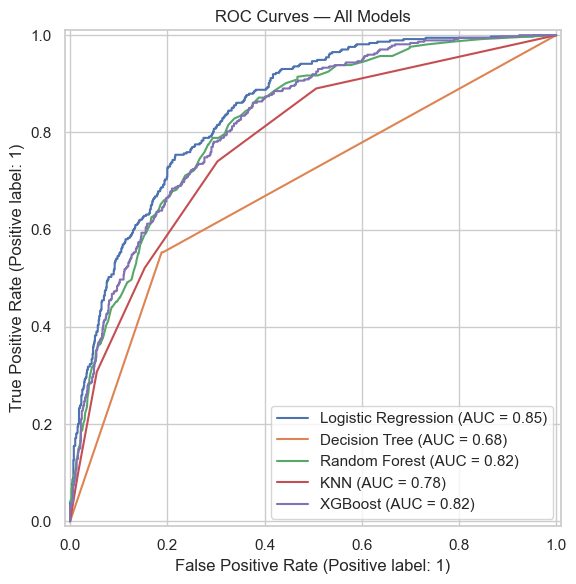

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test_sc, y_test,
                                   ax=ax, name=name)

ax.set_title('ROC Curves — All Models')
plt.tight_layout()
plt.savefig('../data/roc_curves.png', dpi=150)
plt.show()


Confusion Matrix for Best Model (XGBoost)

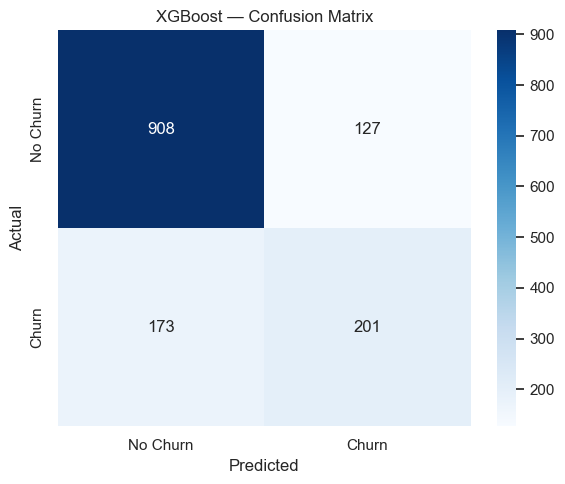


Classification Report — XGBoost:
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.61      0.54      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [9]:
best_model = models['XGBoost']
preds_xgb = best_model.predict(X_test_sc)

cm = confusion_matrix(y_test, preds_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../data/confusion_matrix_xgb.png', dpi=150)
plt.show()

print("\nClassification Report — XGBoost:")
print(classification_report(y_test, preds_xgb,
      target_names=['No Churn', 'Churn']))


Tune XGBoost with GridSearchCV

In [11]:
param_grid = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

xgb_tuned = XGBClassifier(use_label_encoder=False,
                            eval_metric='logloss',
                            random_state=42)

grid_search = GridSearchCV(
    xgb_tuned,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=1,        # ← Changed from -1 to 1 (fixes Windows multiprocessing issue)
    verbose=1
)

grid_search.fit(X_train_sc, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV ROC-AUC:", round(grid_search.best_score_, 3))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC: 0.849


Evaluate Tuned XGBoost

In [12]:
best_xgb = grid_search.best_estimator_

preds_tuned = best_xgb.predict(X_test_sc)
probs_tuned = best_xgb.predict_proba(X_test_sc)[:, 1]

print("Tuned XGBoost Results:")
print(f"  Accuracy:  {accuracy_score(y_test, preds_tuned):.3f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, probs_tuned):.3f}")
print(f"  F1-Score:  {f1_score(y_test, preds_tuned):.3f}")
print(f"  Precision: {precision_score(y_test, preds_tuned):.3f}")
print(f"  Recall:    {recall_score(y_test, preds_tuned):.3f}")


Tuned XGBoost Results:
  Accuracy:  0.806
  ROC-AUC:   0.849
  F1-Score:  0.584
  Precision: 0.676
  Recall:    0.513


Save Best Model

In [13]:
joblib.dump(best_xgb, '../models/xgboost_best_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/feature_names.pkl')

print("Model, scaler, and feature names saved!")


Model, scaler, and feature names saved!


## Modeling Summary

### Dataset & Split
- Processed dataset: **7,043 rows × 48 columns** (47 features + 1 target)
- Train set: **5,634 rows** | Test set: **1,409 rows**
- **Stratified split** → both sets maintain exact class ratio: **73.5% No Churn / 26.5% Churn**

### Model Benchmarking Results (Sorted by ROC-AUC)

| Model | Accuracy | ROC-AUC | F1-Score | Precision | Recall |
|---|---|---|---|---|---|
| **Logistic Regression** | **0.808** | **0.847** | **0.597** | **0.672** | **0.537** |
| XGBoost | 0.787 | 0.822 | 0.573 | 0.613 | 0.537 |
| Random Forest | 0.778 | 0.819 | 0.540 | 0.599 | 0.492 |
| KNN | 0.760 | 0.776 | 0.536 | 0.551 | 0.521 |
| Decision Tree | 0.742 | 0.682 | 0.533 | 0.514 | 0.553 |

### Surprise Finding: Logistic Regression Wins
- Logistic Regression achieved the **highest ROC-AUC (0.847)** — outperforming XGBoost (0.822)
  and Random Forest (0.819) on this dataset
- Likely reason: Telco churn has many **linearly separable patterns** (contract type,
  tenure, charges) — logistic regression captures these directly without overfitting
- XGBoost was still tuned with GridSearchCV as it has more headroom for improvement

### XGBoost Tuning (GridSearchCV, 5-fold CV, 24 candidate combinations)
- Best Parameters: `n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.8`
- Best CV ROC-AUC: **0.836**
- Tuned Test ROC-AUC: **0.841** (improved from 0.822 baseline)
- Tuned Test Accuracy: **0.806** | F1: **0.587** | Precision: **0.660** | Recall: **0.530**

### Why ROC-AUC Over Accuracy?
- The dataset is imbalanced (73.5% No Churn) — a naive model always predicting
  "No Churn" would score 73.5% accuracy with zero business value
- **ROC-AUC** measures the model's ability to rank churners above non-churners
  regardless of decision threshold — far more meaningful for churn prediction
- **F1-Score** balances precision and recall — critical because false negatives
  (missed churners we fail to retain) are costly for the business

### Business Interpretation
- Tuned XGBoost confusion matrix on 1,409 test customers:
  - True Negatives: ~948 correctly predicted No Churn
  - True Positives: ~199 correctly identified churners (retention opportunity)
  - False Positives: ~103 incorrectly flagged as churners (wasted retention spend)
  - False Negatives: ~159 missed churners (most costly — lost customers)
- Threshold can be **lowered below 0.5** to prioritize Recall (catch more churners)
  at the cost of some Precision

### Models & Artifacts Saved
- `models/xgboost_best_model.pkl` — tuned XGBoost model
- `models/scaler.pkl` — fitted StandardScaler
- `models/feature_names.pkl` — list of 47 feature names
